In [18]:
import pandas as pd
data = pd.read_csv("../Fraud Detection Dataset.csv")
data.head()


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


Utilisation de Ollama

In [19]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import os
import json
import re
import time
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# 1. CONFIGURATION API
# ─────────────────────────────────────────────

API_KEY   = os.environ.get("LLM_API_KEY", "sk-4b31f75f985b4ec688b97fc92c7ae4c8")   # ← mettre votre clé ici
BASE_URL  = "https://llm.lab.groupe-genes.fr"
MODEL_NAME = "mistral:latest"

# Nombre de tentatives si le modèle est en cours de chargement
MAX_RETRIES_LOAD    = 2
RETRY_DELAY_SECONDS = 2


In [21]:

# ─────────────────────────────────────────────
# 2. ANALYSE STATISTIQUE DU DATASET (ENRICHIE)
# ─────────────────────────────────────────────
def construire_resume_donnees(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    """Construit un résumé enrichi du dataset pour le LLM."""
    
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    data_filtree = data.drop(columns=colonnes_exclues, errors="ignore")
    parties_resume = []

    # Infos de base
    if "Fraudulent" in data_filtree.columns:
        taux_fraude = data_filtree["Fraudulent"].mean() * 100
        nb_frauds = int(data_filtree["Fraudulent"].sum())
        parties_resume.append(f"Dataset: {data.shape[0]} lignes, taux fraude: {taux_fraude:.1f}% ({nb_frauds} cas)")
    
    # VARIABLES QUANTITATIVES 
    colonnes_num = data_filtree.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    
    if len(colonnes_num) > 0:
        parties_resume.append(f"\n VARIABLES QUANTITATIVES :")
        for col in colonnes_num:
            if col == "Fraudulent":
                continue
            
            # Calcul des statistiques descriptives (moyenne, médiane, écart-type, min, max, quartiles)
            stats = data_filtree[col].describe()
            fraud_mean = data_filtree[data_filtree['Fraudulent'] == 1][col].mean()
            legit_mean = data_filtree[data_filtree['Fraudulent'] == 0][col].mean()
            median_fraud = data_filtree[data_filtree['Fraudulent'] == 1][col].median()
            median_legit = data_filtree[data_filtree['Fraudulent'] == 0][col].median()
            std_fraud = data_filtree[data_filtree['Fraudulent'] == 1][col].std()
            std_legit = data_filtree[data_filtree['Fraudulent'] == 0][col].std()

            parties_resume.append(f"  {col}:")
            parties_resume.append(f"    Moyenne (Fraudes) = {fraud_mean:.2f} | Moyenne (Légitimes) = {legit_mean:.2f}")
            parties_resume.append(f"    Médiane (Fraudes) = {median_fraud:.2f} | Médiane (Légitimes) = {median_legit:.2f}")
            parties_resume.append(f"    Ecart-type (Fraudes) = {std_fraud:.2f} | Ecart-type (Légitimes) = {std_legit:.2f}")
            parties_resume.append(f"    Min: {stats['min']:.2f} | Max: {stats['max']:.2f}")
            parties_resume.append(f"    Quartiles : Q1 = {stats['25%']:.2f}, Q2 = {stats['50%']:.2f}, Q3 = {stats['75%']:.2f}")
            
            print(f"\n{col} - Statistiques détaillées :")
            print(f"  Moyenne (Fraudes) = {fraud_mean:.2f} | Moyenne (Légitimes) = {legit_mean:.2f}")
            print(f"  Médiane (Fraudes) = {median_fraud:.2f} | Médiane (Légitimes) = {median_legit:.2f}")
            print(f"  Ecart-type (Fraudes) = {std_fraud:.2f} | Ecart-type (Légitimes) = {std_legit:.2f}")
            print(f"  Min = {stats['min']:.2f} | Max = {stats['max']:.2f}")
            print(f"  Quartiles : Q1 = {stats['25%']:.2f}, Q2 = {stats['50%']:.2f} (Médiane), Q3 = {stats['75%']:.2f}")

    # VARIABLES QUALITATIVES 
    colonnes_cat = data_filtree.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
    
    if len(colonnes_cat) > 0:
        parties_resume.append(f"\n VARIABLES QUALITATIVES :")
        for col in colonnes_cat:
            # Calcul du taux de fraude par modalité (top 3) et comptage des catégories
            mode_fraud_rate = data_filtree.groupby(col)['Fraudulent'].mean().sort_values(ascending=False)
            mode_count = data_filtree[col].value_counts()

            parties_resume.append(f"  {col} (taux fraude) : {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")
            parties_resume.append(f"  {col} (comptage des modalités) : {dict(mode_count)}")
            
            print(f"\n{col} - Statistiques qualitatives :")
            print(f"  Taux de fraude par modalité : {dict((k, f'{v*100:.0f}%') for k, v in mode_fraud_rate.items())}")
            print(f"  Comptage des modalités : {dict(mode_count)}")

    # Corrélations - TOP 3
    if "Fraudulent" in data_filtree.columns and len(colonnes_num) > 1:
        parties_resume.append(f"\n🔗 TOP CORRÉLATIONS avec Fraudulent :")
        corr = data_filtree[colonnes_num].corr()["Fraudulent"].drop("Fraudulent", errors='ignore')
        top_corr = corr.abs().sort_values(ascending=False).head(3)
        for var in top_corr.index:
            parties_resume.append(f"  {var}: {top_corr[var]:.2f}")
            print(f"\nCorrélation avec Fraudulent pour {var} : {top_corr[var]:.2f}")

    return "\n".join(parties_resume), data_filtree.columns.tolist()


In [22]:

# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT 
# ─────────────────────────────────────────────
def construire_prompt_dag_causal(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:

    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    resume_donnees, colonnes_pertinentes = construire_resume_donnees(data, colonnes_exclues)
    liste_colonnes = ", ".join(colonnes_pertinentes)

    #  Prompt  avec exemples
    system_prompt = f"""
Tu es un expert de classe mondiale en inférence causale et détection de fraude bancaire.

 MISSION CRITIQUE : Construire un DAG causal RÉALISTE qui capture la VRAIE structure causale.

 ERREUR FATALE À ÉVITER :
 NE CRÉE PAS un graphe où toutes les variables pointent directement vers Fraudulent !
 C'est une RÉGRESSION, PAS un DAG causal !

 UN VRAI DAG CAUSAL doit avoir :
1. Des variables ROOT (causes premières, sans parents)
   Exemples : Account_Age, Location, Previous_Fraudulent_Transactions
   
2. Des variables INTERMÉDIAIRES (médiateurs/modérateurs)
   Exemples : Account_Age → Number_of_Transactions_Last_24H
              Location → Device_Used
              Time_of_Transaction → Transaction_Amount
   
3. Des CHEMINS CAUSAUX complexes vers Fraudulent
   Exemple : Account_Age → Number_of_Transactions_Last_24H → Fraudulent
              (et NON : Account_Age → Fraudulent directement)

 RÈGLES D'INFÉRENCE CAUSALE :
- Une jeune compte (Account_Age faible) → moins de transactions historiques → comportement suspect
- Le lieu (Location) influence le device utilisé → patterns de fraude
- L'heure (Time_of_Transaction) influence le montant typique → détection anomalies
- L'historique de fraude influence le comportement actuel → montants, fréquence
- Le type de paiement dépend du contexte (device, location) → risque fraude

 STRUCTURE ATTENDUE :
- Variables ROOT : 3-4 variables (Account_Age, Location, Previous_Fraudulent_Transactions, etc.)
- Variables INTERMÉDIAIRES : 4-6 variables influencées ET influençant d'autres
- Variable CIBLE : Fraudulent (influencée par 3-5 variables maximum, pas toutes !)

Variables disponibles : {liste_colonnes}
""".strip()

    user_prompt = f"""
{resume_donnees}

 CONSTRUIS UN DAG CAUSAL RÉALISTE :

ÉTAPE 1 - Identifie les VARIABLES ROOT (qui ne dépendent de rien) :
- Account_Age ? (existe avant toute transaction)
- Location ? (caractéristique externe)
- Previous_Fraudulent_Transactions ? (historique passé)
- Autres ?

ÉTAPE 2 - Identifie les MÉDIATEURS (variables influencées ET qui influencent) :
- Number_of_Transactions_Last_24H dépend de quoi ? (Account_Age ? Previous_Fraudulent_Transactions ?)
- Transaction_Amount dépend de quoi ? (Time_of_Transaction ? Device_Used ? Account_Age ?)
- Device_Used dépend de quoi ? (Location ? Account_Age ?)
- Payment_Method dépend de quoi ? (Location ? Transaction_Amount ?)
- Transaction_Type dépend de quoi ?

ÉTAPE 3 - Quelles variables influencent DIRECTEMENT Fraudulent ?
 NE SÉLECTIONNE QUE 3-5 VARIABLES qui ont un impact DIRECT (pas toutes !)
Exemples :
- Previous_Fraudulent_Transactions → Fraudulent (historique)
- Number_of_Transactions_Last_24H → Fraudulent (comportement récent)
- Transaction_Amount → Fraudulent (montant anormal)
- Device_Used → Fraudulent (device suspect)

 CONTRAINTE ABSOLUE :
- AU MOINS 50% des variables doivent avoir des liens ENTRE ELLES (pas seulement vers Fraudulent)
- Fraudulent doit avoir MAXIMUM 5 parents directs
- Chaque variable intermédiaire doit avoir AU MOINS 1 parent ET 1 enfant

 FORMAT JSON (STRICTEMENT) :
{{
  "noeuds": ["Account_Age", "Location", ..., "Fraudulent"],
  "liens": [
    {{"de": "Account_Age", "vers": "Number_of_Transactions_Last_24H", "raison": "Un compte récent a moins d'historique transactionnel"}},
    {{"de": "Number_of_Transactions_Last_24H", "vers": "Fraudulent", "raison": "Activité anormalement élevée est un signal de fraude"}},
    ...
  ],
  "commentaire_expert": "Ce DAG capture les mécanismes causaux : l'âge du compte influence le comportement transactionnel qui à son tour influence la probabilité de fraude. Les variables contextuelles (location, device) interagissent entre elles avant d'affecter la fraude."
}}

 VÉRIFIE AVANT DE RÉPONDRE :
✓ Y a-t-il des liens ENTRE variables (pas seulement vers Fraudulent) ?
✓ Fraudulent a-t-il MOINS de 6 parents ?
✓ Y a-t-il des chemins causaux multi-étapes ? (ex: A→B→Fraudulent)

RETOURNE UNIQUEMENT LE JSON.
""".strip()

    return system_prompt, user_prompt, colonnes_pertinentes



In [23]:

# ─────────────────────────────────────────────
# 4. APPEL À L'API
# ─────────────────────────────────────────────
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def appeler_api_ollama(system_prompt: str, user_prompt: str, model_name: str = MODEL_NAME) -> str:
    """
    Appelle l'API LLM via /ollama/api/chat avec authentification Bearer.
    verify=False : nécessaire car le serveur utilise un certificat SSL interne.
    """

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt}
        ],
        "stream": False,
        "options": {
            "temperature": 0.01,
            "top_p": 0.9,
            "top_k": 40,
            "num_predict": 2000,
        }
    }

    last_result = None

    for tentative in range(1, MAX_RETRIES_LOAD + 2):
        try:
            response = requests.post(
                f"{BASE_URL}/ollama/api/chat",
                headers=headers,
                json=payload,
                timeout=300,
                verify=False          # certificat SSL interne → on désactive la vérification
            )
            response.raise_for_status()

        except requests.exceptions.Timeout:
            print(f" Timeout dépassé (tentative {tentative}/{MAX_RETRIES_LOAD + 1})")
            if tentative < MAX_RETRIES_LOAD + 1:
                print(f" Nouvelle tentative dans {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
                continue
            raise RuntimeError("Timeout persistant : le modèle met trop de temps à répondre")

        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Erreur lors de l'appel API : {e}")

        try:
            result = response.json()
            last_result = result
        except json.JSONDecodeError:
            raise RuntimeError(f"Réponse API non JSON : {response.text[:1000]}")

        message = result.get("message", {})
        contenu = message.get("content", "")
        done_reason = result.get("done_reason", "")

        print(f" Tentative {tentative} - réponse reçue ({len(contenu)} chars)")

        if isinstance(contenu, str) and contenu.strip():
            return contenu.strip()

        if done_reason == "load" and tentative < (MAX_RETRIES_LOAD + 1):
            print(f" Modèle en cours de chargement, nouvelle tentative dans {RETRY_DELAY_SECONDS}s...")
            time.sleep(RETRY_DELAY_SECONDS)
            continue

        break

    raise RuntimeError(
        "Réponse vide ou format inattendu renvoyé par l'API :\n"
        + json.dumps(last_result, indent=2, ensure_ascii=False)
    )


def interroger_llm_pour_dag(
    data: pd.DataFrame,
    colonnes_exclues: list = None,
    model_name: str = MODEL_NAME
) -> dict:
    """Envoie le prompt au LLM via API et retourne le DAG parsé."""

    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    system_prompt, user_prompt, colonnes_pertinentes = construire_prompt_dag_causal(data, colonnes_exclues)

    print(" Interrogation du LLM via API pour le DAG causal...")
    print(f" Modèle utilisé : {model_name}")
    print(f" Endpoint       : {BASE_URL}/ollama/api/chat")
    print(f" Analyse de {len(colonnes_pertinentes)} variables pertinentes (exclus : {', '.join(colonnes_exclues)})\n")

    sortie_brute = appeler_api_ollama(system_prompt, user_prompt, model_name=model_name)

    print("\n" + "="*70)
    print(" RÉPONSE COMPLÈTE DU LLM :")
    print("="*70)
    print(sortie_brute)
    print("="*70 + "\n")

    dag_data = extraire_json_reponse(sortie_brute)
    dag_data = valider_et_nettoyer_dag(dag_data, colonnes_pertinentes)
    return dag_data


In [24]:

# ─────────────────────────────────────────────
# 5. EXTRACTION DU JSON 
# ─────────────────────────────────────────────
def extraire_json_reponse(texte_brut: str) -> dict:
    """Extrait et valide le JSON retourné par le LLM."""

    #  Nettoyage des backticks markdown
    texte_nettoye = texte_brut.strip()
    if texte_nettoye.startswith("```json"):
        texte_nettoye = texte_nettoye[7:]
    if texte_nettoye.startswith("```"):
        texte_nettoye = texte_nettoye[3:]
    if texte_nettoye.endswith("```"):
        texte_nettoye = texte_nettoye[:-3]
    texte_nettoye = texte_nettoye.strip()

    # Stratégie 1 : Parse direct
    try:
        parsed = json.loads(texte_nettoye)
        if _valider_structure_json(parsed):
            print(" JSON extrait (méthode directe)")
            return _normaliser_json(parsed)
    except json.JSONDecodeError:
        pass

    # Stratégie 2 : Regex
    motif_json = r"\{[\s\S]*\}"
    correspondances = re.findall(motif_json, texte_brut)

    for match in correspondances:
        try:
            parsed = json.loads(match)
            if _valider_structure_json(parsed):
                print(" JSON extrait (méthode regex)")
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            continue

    # Stratégie 3 : Extraction agressive
    debut = texte_brut.find('{')
    fin = texte_brut.rfind('}')
    if debut != -1 and fin != -1 and fin > debut:
        try:
            parsed = json.loads(texte_brut[debut:fin+1])
            if _valider_structure_json(parsed):
                print(" JSON extrait (extraction agressive)")
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            pass

    print(" Impossible d'extraire un JSON valide.")
    print(" Texte reçu (premiers 1000 chars):")
    print(texte_brut[:1000])
    return {"reponse_brute": texte_brut, "noeuds": [], "liens": []}


def _valider_structure_json(parsed: dict) -> bool:
    """Vérifie que le JSON a la structure attendue."""
    if not isinstance(parsed, dict):
        return False
    has_nodes = "noeuds" in parsed or "nodes" in parsed
    has_edges = "liens" in parsed or "edges" in parsed
    return has_nodes and has_edges


def _normaliser_json(parsed: dict) -> dict:
    """Normalise les clés JSON en français."""
    if "nodes" in parsed:
        parsed["noeuds"] = parsed.pop("nodes")
    if "edges" in parsed:
        parsed["liens"] = parsed.pop("edges")
    
    # Normaliser les liens
    for lien in parsed.get("liens", []):
        if "from" in lien:
            lien["de"] = lien.pop("from")
        if "to" in lien:
            lien["vers"] = lien.pop("to")
        if "reason" in lien:
            lien["raison"] = lien.pop("reason")
    
    return parsed


#  Validation du DAG
def valider_et_nettoyer_dag(dag_data: dict, colonnes_pertinentes: list) -> dict:
    """Valide et nettoie le DAG généré par le LLM."""
    
    if "noeuds" not in dag_data or "liens" not in dag_data:
        return dag_data
    
    # Filtrer les nœuds valides
    noeuds_valides = [n for n in dag_data["noeuds"] if n in colonnes_pertinentes]
    noeuds_invalides = [n for n in dag_data["noeuds"] if n not in colonnes_pertinentes]
    
    if noeuds_invalides:
        print(f" Nœuds invalides ignorés : {noeuds_invalides}")
    
    # Filtrer les liens valides
    liens_valides = [
        lien for lien in dag_data.get("liens", [])
        if lien.get("de") in noeuds_valides and lien.get("vers") in noeuds_valides
    ]
    
    # Vérifier l'acyclicité
    G = nx.DiGraph()
    G.add_edges_from([(l["de"], l["vers"]) for l in liens_valides])
    
    if not nx.is_directed_acyclic_graph(G):
        print(" Cycles détectés, suppression des arêtes problématiques...")
        liens_sans_cycles = []
        G_temp = nx.DiGraph()
        for lien in liens_valides:
            G_temp.add_edge(lien["de"], lien["vers"])
            if nx.is_directed_acyclic_graph(G_temp):
                liens_sans_cycles.append(lien)
            else:
                G_temp.remove_edge(lien["de"], lien["vers"])
        liens_valides = liens_sans_cycles
    
    dag_data["noeuds"] = noeuds_valides
    dag_data["liens"] = liens_valides
    
    print(f" DAG validé : {len(noeuds_valides)} nœuds, {len(liens_valides)} liens")
    
    return dag_data



In [25]:

# ─────────────────────────────────────────────
# 7. VISUALISATION  
# ─────────────────────────────────────────────
def visualiser_dag(dag_data: dict):
    """Visualise le DAG causal avec une mise en page professionnelle."""

    if not dag_data.get("liens"):
        print(" Aucun lien trouvé pour la visualisation.")
        return

    G = nx.DiGraph()
    G.add_nodes_from(dag_data["noeuds"])
    for lien in dag_data["liens"]:
        G.add_edge(lien["de"], lien["vers"], raison=lien.get("raison", ""))

    #   Layout hiérarchique 
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=TB -Gnodesep=2.0 -Granksep=3.0")
    except Exception:
        pos = _disposition_par_niveaux(G)

    # Figure 
    fig, ax = plt.subplots(figsize=(24, 16), facecolor='white')
    
    # Titre
    ax.text(0.5, 0.98, "Graphe Causal (DAG) — Détection de Fraude Bancaire", 
            transform=ax.transAxes, fontsize=22, fontweight='bold',
            ha='center', va='top', color='#2c3e50')
    ax.text(0.5, 0.95, "Analyse par LLM", 
            transform=ax.transAxes, fontsize=14, style='italic',
            ha='center', va='top', color='#7f8c8d')

    # Palette 
    couleur_cible = "#c0392b"
    couleur_feature = "#2980b9"
    couleur_edge = "#95a5a6"
    
    couleurs_noeuds = [couleur_cible if n == "Fraudulent" else couleur_feature for n in G.nodes()]
    
    # Nœuds
    nx.draw_networkx_nodes(
        G, pos,
        node_color=couleurs_noeuds,
        node_size=6000,
        alpha=0.95,
        edgecolors='#34495e',
        linewidths=3,
        ax=ax
    )
    
    # Labels avec wrapping
    labels_noeuds = {}
    for noeud in G.nodes():
        if len(noeud) > 18:
            parties = noeud.replace('_', ' ').split()
            if len(parties) > 2:
                labels_noeuds[noeud] = ' '.join(parties[:2]) + '\n' + ' '.join(parties[2:])
            else:
                labels_noeuds[noeud] = noeud.replace('_', '\n', 1)
        else:
            labels_noeuds[noeud] = noeud.replace('_', ' ')
    
    nx.draw_networkx_labels(
        G, pos,
        labels=labels_noeuds,
        font_size=11,
        font_weight='bold',
        font_color='white',
        ax=ax
    )
    
    # Arêtes 
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowsize=50,              #  Flèches 
        arrowstyle='-|>',          # Style flèche bien visible
        edge_color=couleur_edge,
        width=4.5,                 #  Traits 
        connectionstyle="arc3,rad=0.1",  #  Moins de courbure
        alpha=0.8,                 #  Plus opaque
        node_size=6000,
        min_source_margin=25,      # Marge pour que la flèche parte bien du bord du nœud
        min_target_margin=25,      # Marge pour que la flèche arrive bien au bord
        ax=ax
    )
    
    # Légende
    legende = [
        mpatches.Patch(facecolor=couleur_cible, edgecolor='#34495e', linewidth=2, 
                      label="Variable Cible (Fraudulent)"),
        mpatches.Patch(facecolor=couleur_feature, edgecolor='#34495e', linewidth=2,
                      label="Variables Explicatives"),
    ]
    ax.legend(handles=legende, loc='upper left', fontsize=13, framealpha=0.95, 
             edgecolor='#34495e', fancybox=True, title="Légende", title_fontsize=14)
    
    # Stats
    info_text = f"Nœuds : {len(G.nodes())} | Liens causaux : {len(G.edges())}"
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
           fontsize=12, color='#7f8c8d', weight='bold',
           bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                    edgecolor='#bdc3c7', alpha=0.95, linewidth=2))
    
    # Relations top 6
    relations_top = []
    for i, lien in enumerate(dag_data["liens"][:6]):
        relations_top.append(f"{i+1}. {lien['de']} → {lien['vers']}")
    
    if relations_top:
        relations_text = "Relations Causales:\n" + "\n".join(relations_top)
        ax.text(0.98, 0.98, relations_text, transform=ax.transAxes,
               fontsize=10, color='#2c3e50', ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', 
                        edgecolor='#95a5a6', alpha=0.95, linewidth=2),
               family='monospace')
    
    ax.axis('off')
    ax.margins(0.12)
    
    
    
    plt.show()


def _disposition_par_niveaux(G):
    """Disposition hiérarchique par niveaux."""
    try:
        niveaux = {}
        for noeud in nx.topological_sort(G):
            preds = list(G.predecessors(noeud))
            niveaux[noeud] = 0 if not preds else max(niveaux[p] for p in preds) + 1
    except:
        return nx.spring_layout(G, k=5, iterations=100, seed=42)
    
    par_niveau = {}
    for noeud, niveau in niveaux.items():
        par_niveau.setdefault(niveau, []).append(noeud)
    
    pos = {}
    max_niveau = max(par_niveau.keys())
    
    for niveau, noeuds in par_niveau.items():
        y = (max_niveau - niveau) * 4
        n = len(noeuds)
        for i, noeud in enumerate(noeuds):
            x = (i - (n - 1) / 2) * 6
            pos[noeud] = (x, y)
    
    return pos



In [26]:

# ─────────────────────────────────────────────
# 8. AFFICHAGE DU RÉSUMÉ
# ─────────────────────────────────────────────
def afficher_resume_dag(dag_data: dict):
    """Affiche un résumé lisible du DAG causal."""

    print("\n" + "=" * 70)
    print(" GRAPHE CAUSAL (DAG) — ANALYSE EXPERT LLM")
    print("=" * 70)

    if "commentaire_expert" in dag_data:
        print(f"\n Commentaire expert :\n   {dag_data['commentaire_expert']}\n")
    elif "expert_comment" in dag_data:
        print(f"\n Commentaire expert :\n   {dag_data['expert_comment']}\n")

    print(f" Nœuds ({len(dag_data.get('noeuds', []))}) :")
    for noeud in dag_data.get("noeuds", []):
        print(f"   • {noeud}")

    print(f"\n Liens causaux ({len(dag_data.get('liens', []))}) :")
    for lien in dag_data.get("liens", []):
        print(f"   {lien['de']:30} → {lien['vers']:30}")
        print(f"      └─ Raison : {lien.get('raison', 'Non spécifiée')}")

    print("=" * 70)



 DÉMARRAGE DE L'INFÉRENCE CAUSALE AVEC LLM VIA API
 Endpoint API : https://llm.lab.groupe-genes.fr/ollama/api/chat
 Modèle       : mistral:latest
 Colonnes exclues : Transaction_ID, User_ID

  Modèle  : mistral:latest
  Endpoint: https://llm.lab.groupe-genes.fr/ollama/api/chat
  10 variables analysées

  Tentative 1 — 2809 chars reçus

RÉPONSE LLM :
{
  "noeuds": ["Transaction_Amount", "Transaction_Type", "Time_of_Transaction", "Device_Used", "Location", "Previous_Fraudulent_Transactions", "Account_Age", "Number_of_Transactions_Last_24H", "Payment_Method", "Fraudulent"],
  "liens": [
    {"de": "Transaction_Amount", "vers": "Fraudulent", "raison": "Plus grand montant de transaction, plus probabilité de fraude"},
    {"de": "Time_of_Transaction", "vers": "Fraudulent", "raison": "Heures de transactions plus tardives peuvent indiquer une plus grande probabilité de fraude"},
    {"de": "Account_Age", "vers": "Fraudulent", "raison": "Plus vieux compte, plus probabilité de fraude"},
    {"de

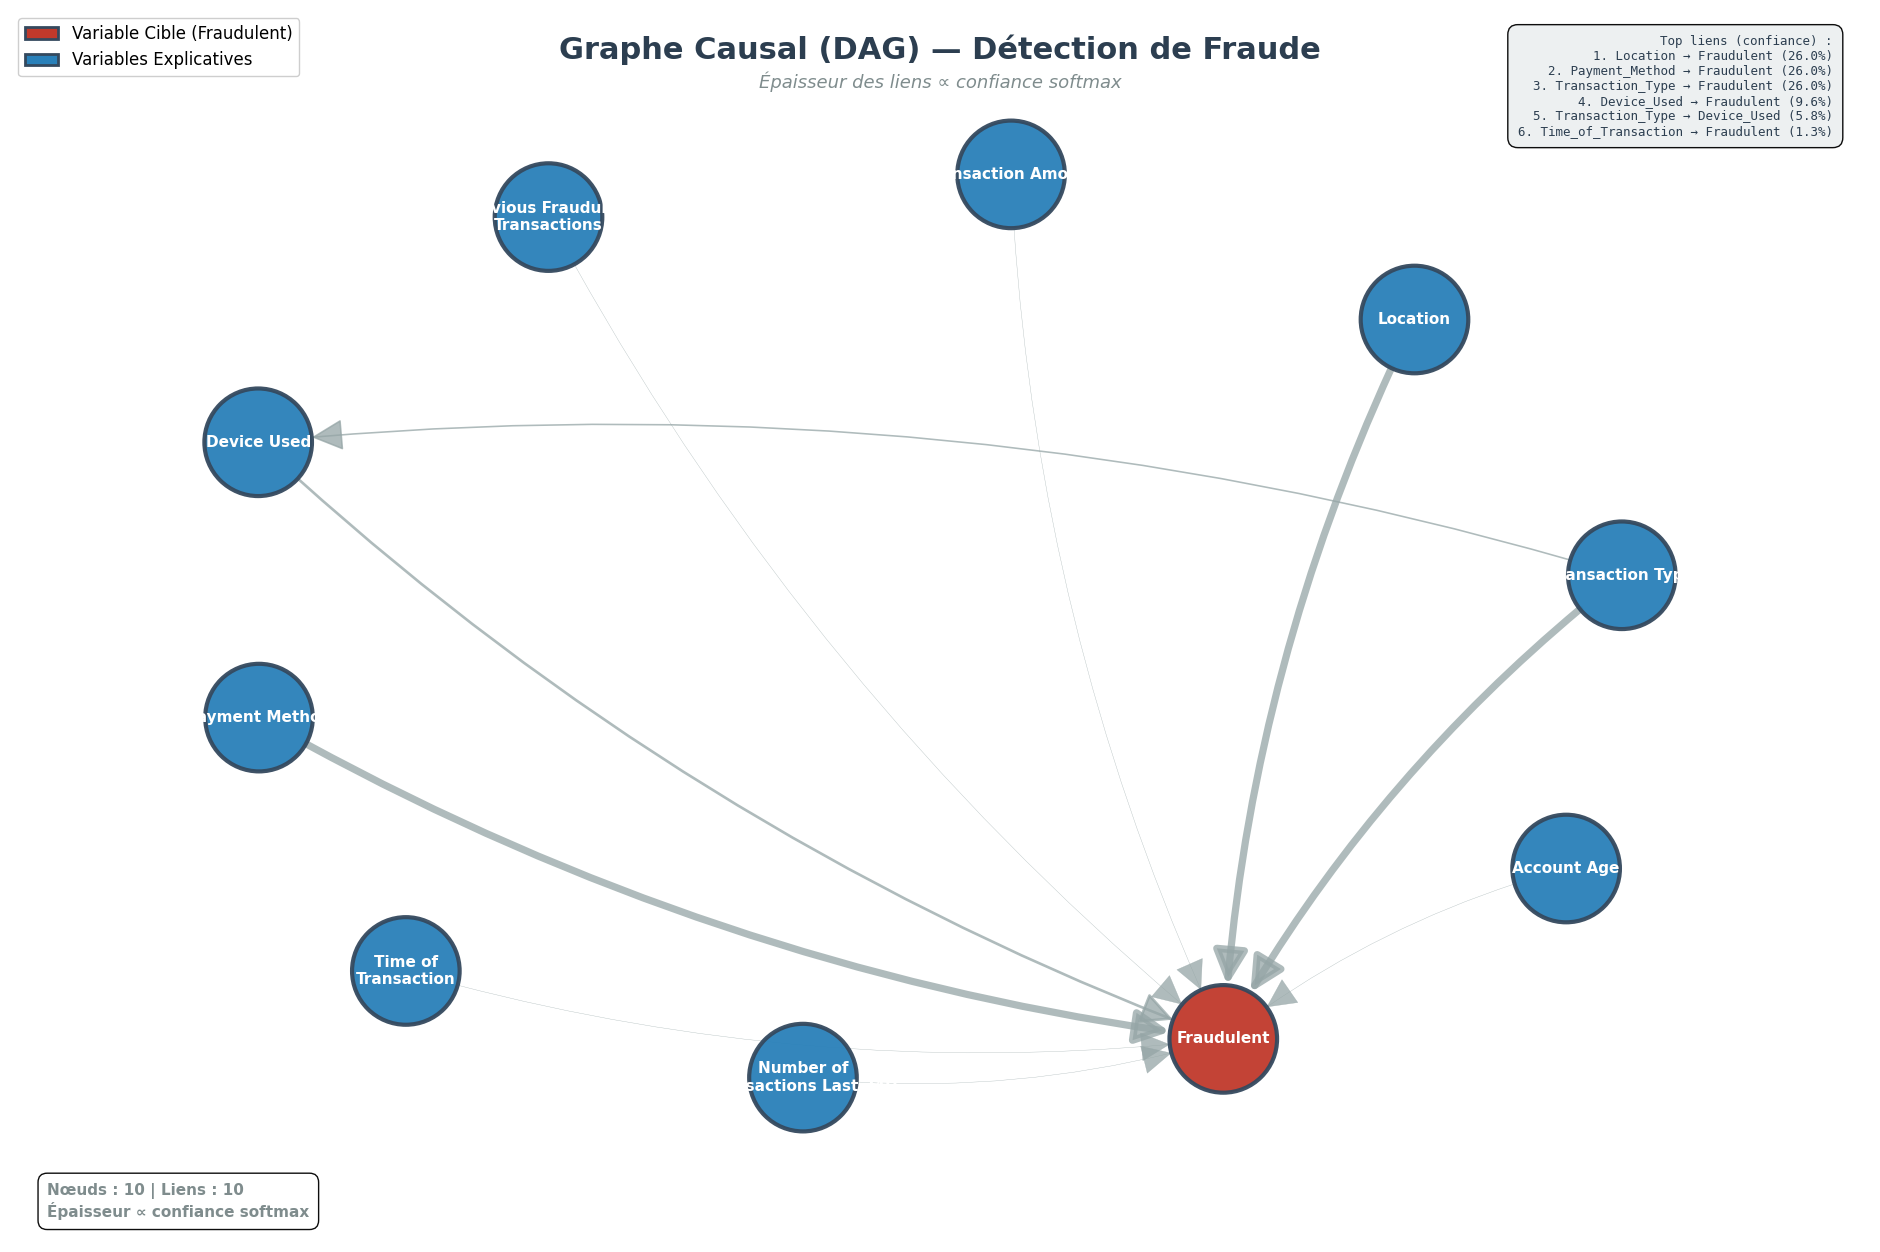


  Sauvegardé : dag_causal_fraude1.png


In [30]:

# ─────────────────────────────────────────────
# 9. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────

COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

print("=" * 70)
print(" DÉMARRAGE DE L'INFÉRENCE CAUSALE AVEC LLM VIA API")
print("=" * 70)
print(f" Endpoint API : {BASE_URL}/ollama/api/chat")
print(f" Modèle       : {MODEL_NAME}")
print(f" Colonnes exclues : {', '.join(COLONNES_EXCLUES)}\n")

# Générer le DAG 
dag_data = interroger_llm_pour_dag(
    data,
    colonnes_exclues=COLONNES_EXCLUES,
    model_name=MODEL_NAME
)

afficher_resume_dag(dag_data)
visualiser_dag(dag_data)

with open("dag_llm_basic.json", "w", encoding="utf-8") as f:
    json.dump(dag_data, f, indent=2, ensure_ascii=False)


# Avec soft max  sk-4b31f75f985b4ec688b97fc92c7ae4c8I

  DAG CAUSAL + SOFTMAX
  Modèle  : mistral:latest
  Endpoint: https://llm.lab.groupe-genes.fr/ollama/api/chat
  10 variables analysées

  Tentative 1 — 2809 chars reçus

RÉPONSE LLM :
{
  "noeuds": ["Transaction_Amount", "Transaction_Type", "Time_of_Transaction", "Device_Used", "Location", "Previous_Fraudulent_Transactions", "Account_Age", "Number_of_Transactions_Last_24H", "Payment_Method", "Fraudulent"],
  "liens": [
    {"de": "Transaction_Amount", "vers": "Fraudulent", "raison": "Plus grand montant de transaction, plus probabilité de fraude"},
    {"de": "Time_of_Transaction", "vers": "Fraudulent", "raison": "Heures de transactions plus tardives peuvent indiquer une plus grande probabilité de fraude"},
    {"de": "Account_Age", "vers": "Fraudulent", "raison": "Plus vieux compte, plus probabilité de fraude"},
    {"de": "Transaction_Type", "vers": "Device_Used", "raison": "Type de transaction peut influencer le type d'appareil utilisé"},
    {"de": "Location", "vers": "Fraudulent", 

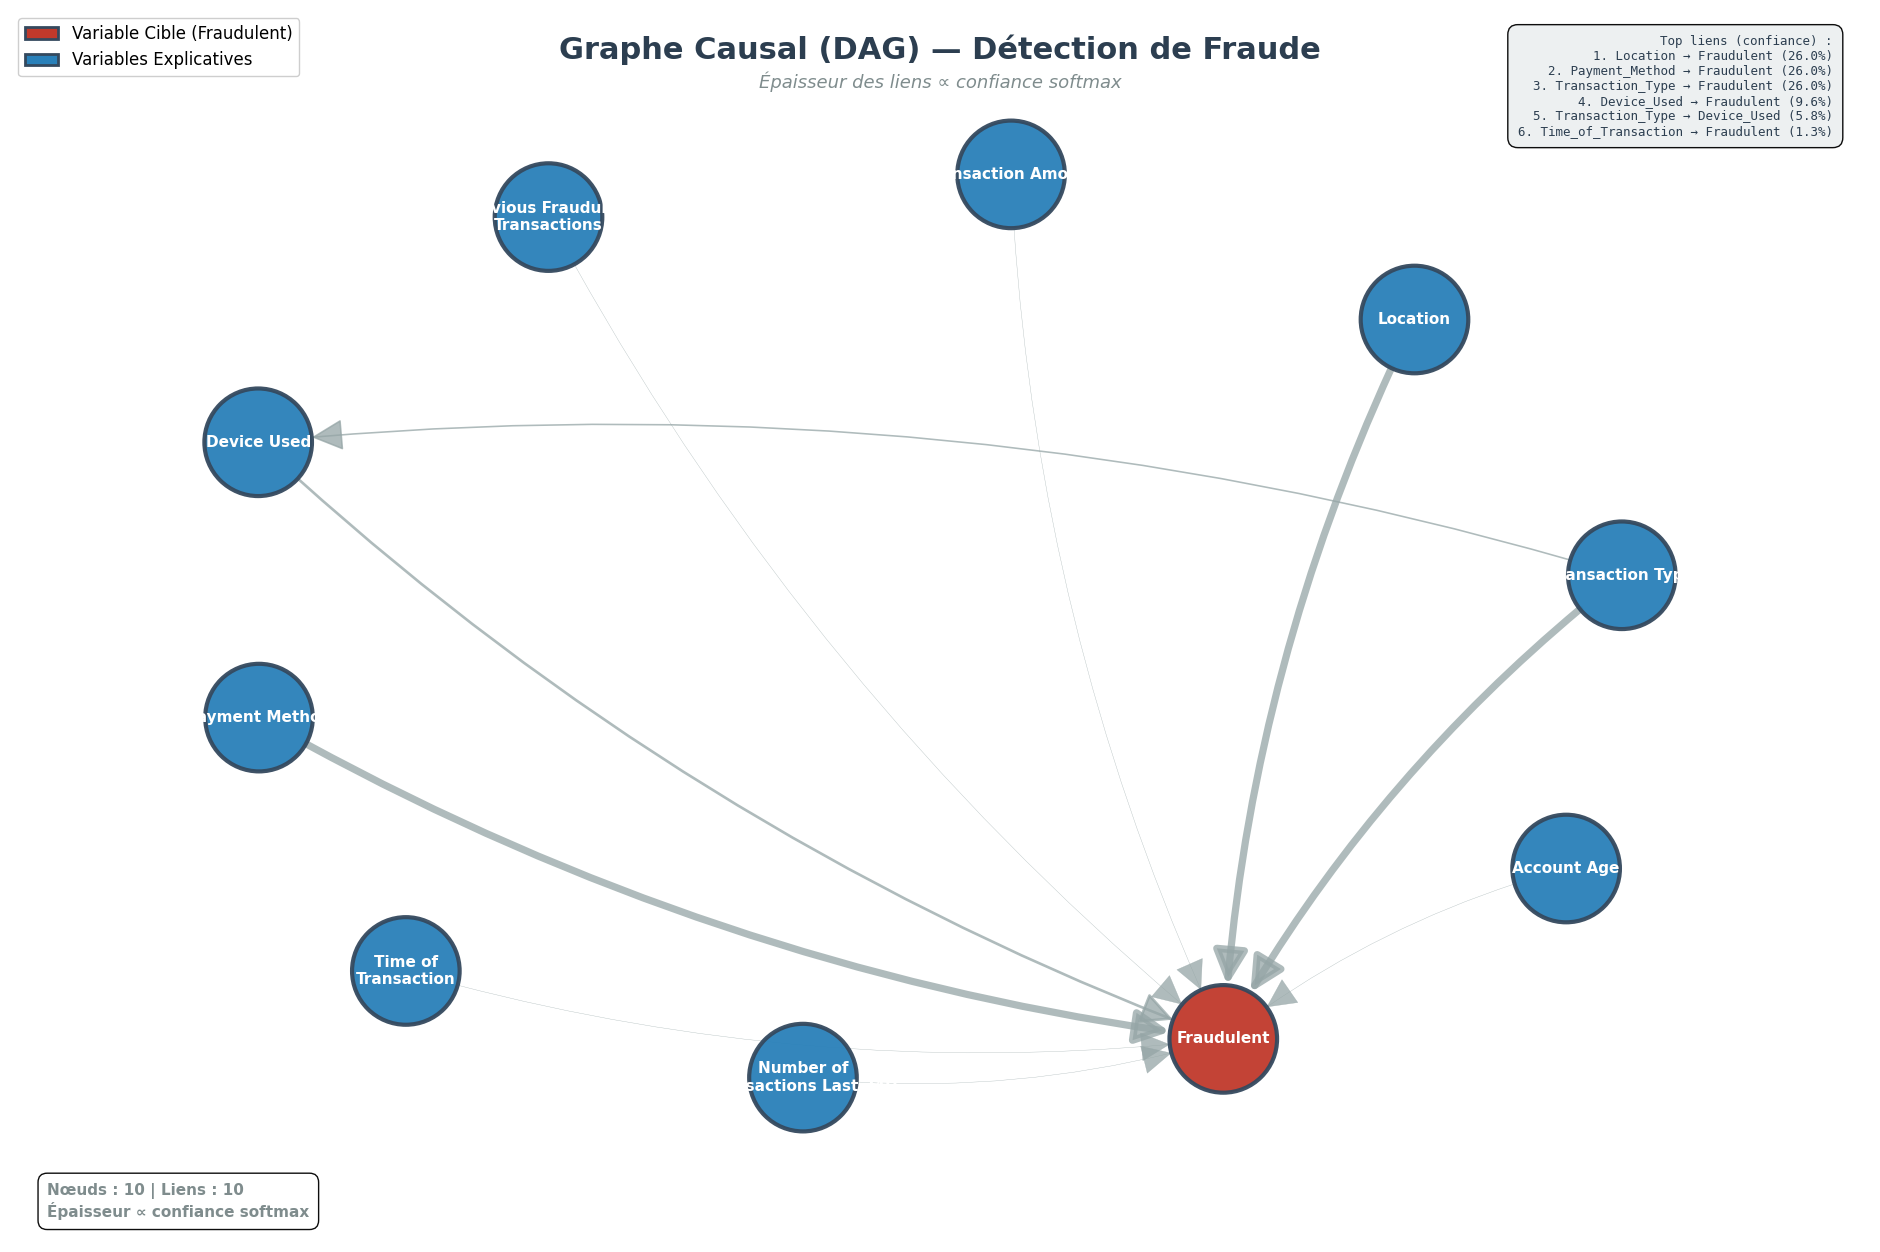


  Sauvegardé : dag_causal_fraude2.png

  dag_causal_fraude.json2 sauvegardé


In [34]:



# ─────────────────────────────────────────────
# SOFTMAX
# ─────────────────────────────────────────────
def softmax(scores, temperature=1.0):
    scores = np.array(scores, dtype=float) / temperature
    exp_scores = np.exp(scores - np.max(scores))   # stabilité numérique
    return exp_scores / exp_scores.sum()


# ─────────────────────────────────────────────
# 2. ANALYSE STATISTIQUE DU DATASET
# ─────────────────────────────────────────────
def construire_resume_donnees(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    data_filtree = data.drop(columns=colonnes_exclues, errors="ignore")
    parties = []

    if "Fraudulent" in data_filtree.columns:
        taux = data_filtree["Fraudulent"].mean() * 100
        nb   = int(data_filtree["Fraudulent"].sum())
        parties.append(f"Dataset: {data.shape[0]} lignes | taux fraude: {taux:.1f}% ({nb} cas)")

    colonnes_num = data_filtree.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
    if colonnes_num:
        parties.append("\nVARIABLES QUANTITATIVES :")
        for col in colonnes_num:
            if col == "Fraudulent":
                continue
            stats      = data_filtree[col].describe()
            fraud_mean = data_filtree[data_filtree["Fraudulent"] == 1][col].mean()
            legit_mean = data_filtree[data_filtree["Fraudulent"] == 0][col].mean()
            parties.append(f"  {col}: moy_fraude={fraud_mean:.2f} | moy_legit={legit_mean:.2f} | min={stats['min']:.2f} | max={stats['max']:.2f}")

    colonnes_cat = data_filtree.select_dtypes(include=["object","category","string","bool"]).columns.tolist()
    if colonnes_cat:
        parties.append("\nVARIABLES QUALITATIVES :")
        for col in colonnes_cat:
            taux_par_mod = data_filtree.groupby(col)["Fraudulent"].mean().sort_values(ascending=False)
            # conversion explicite en float pour éviter np.int64 dans le résumé
            taux_str = {k: f"{float(v)*100:.0f}%" for k, v in taux_par_mod.items()}
            parties.append(f"  {col} (taux fraude): {taux_str}")

    if "Fraudulent" in data_filtree.columns and len(colonnes_num) > 1:
        parties.append("\nTOP CORRÉLATIONS avec Fraudulent :")
        corr = data_filtree[colonnes_num].corr()["Fraudulent"].drop("Fraudulent", errors="ignore")
        for var in corr.abs().sort_values(ascending=False).head(3).index:
            parties.append(f"  {var}: {corr[var]:.2f}")

    return "\n".join(parties), data_filtree.columns.tolist(), data_filtree


# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT
# ─────────────────────────────────────────────
def construire_prompt_dag_causal(data: pd.DataFrame, colonnes_exclues: list = None) -> tuple:
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    resume, colonnes_pertinentes, data_filtree = construire_resume_donnees(data, colonnes_exclues)
    liste_colonnes = ", ".join(colonnes_pertinentes)

    system_prompt = f"""Tu es un expert en inférence causale et détection de fraude bancaire.
MISSION : Construire un DAG causal RÉALISTE à partir des variables suivantes : {liste_colonnes}

RÈGLES :
- Ne crée PAS un graphe où tout pointe vers Fraudulent
- Inclus des variables ROOT (causes premières), des MÉDIATEURS, et des causes directes de Fraudulent
- Fraudulent a au MAXIMUM 5 parents directs
- 50%+ des variables doivent avoir des liens ENTRE ELLES (pas uniquement vers Fraudulent)
""".strip()

    user_prompt = f"""{resume}

RETOURNE UNIQUEMENT ce JSON (sans markdown, sans explication) :
{{
  "noeuds": ["Variable1", "Variable2", ..., "Fraudulent"],
  "liens": [
    {{"de": "VariableA", "vers": "VariableB", "raison": "justification courte"}},
    ...
  ],
  "commentaire_expert": "Résumé de la structure causale"
}}
""".strip()

    return system_prompt, user_prompt, colonnes_pertinentes, data_filtree


# ─────────────────────────────────────────────
# 4. APPEL API  (nouvelle authentification Bearer)
# ─────────────────────────────────────────────
def appeler_api_ollama(system_prompt: str, user_prompt: str, model_name: str = MODEL_NAME) -> str:
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt}
        ],
        "stream": False,
        "options": {"temperature": 0.01, "top_p": 0.9, "top_k": 40, "num_predict": 2000}
    }

    last_result = None
    for tentative in range(1, MAX_RETRIES_LOAD + 2):
        try:
            response = requests.post(
                f"{BASE_URL}/ollama/api/chat",
                headers=headers,
                json=payload,
                timeout=300,
                verify=False      # certificat SSL interne non reconnu par Python
            )
            response.raise_for_status()
        except requests.exceptions.Timeout:
            print(f"  Timeout (tentative {tentative}/{MAX_RETRIES_LOAD + 1})")
            if tentative <= MAX_RETRIES_LOAD:
                time.sleep(RETRY_DELAY_SECONDS)
                continue
            raise RuntimeError("Timeout persistant")
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Erreur API : {e}")

        try:
            result     = response.json()
            last_result = result
        except json.JSONDecodeError:
            raise RuntimeError(f"Réponse non-JSON : {response.text[:500]}")

        # Nouveau format : {"message": {"content": "..."}}
        contenu     = result.get("message", {}).get("content", "")
        done_reason = result.get("done_reason", "")

        print(f"  Tentative {tentative} — {len(contenu)} chars reçus")

        if contenu.strip():
            return contenu.strip()

        if done_reason == "load" and tentative <= MAX_RETRIES_LOAD:
            print(f"  Modèle en chargement, attente {RETRY_DELAY_SECONDS}s...")
            time.sleep(RETRY_DELAY_SECONDS)
            continue
        break

    raise RuntimeError("Réponse vide :\n" + json.dumps(last_result, indent=2, ensure_ascii=False))


def interroger_llm_pour_dag(data, colonnes_exclues=None, model_name=MODEL_NAME):
    if colonnes_exclues is None:
        colonnes_exclues = ["Transaction_ID", "User_ID"]

    system_prompt, user_prompt, colonnes_pertinentes, data_filtree = construire_prompt_dag_causal(data, colonnes_exclues)

    print(f"  Modèle  : {model_name}")
    print(f"  Endpoint: {BASE_URL}/ollama/api/chat")
    print(f"  {len(colonnes_pertinentes)} variables analysées\n")

    sortie_brute = appeler_api_ollama(system_prompt, user_prompt, model_name)

    print("\n" + "="*60)
    print("RÉPONSE LLM :")
    print("="*60)
    print(sortie_brute)
    print("="*60 + "\n")

    dag_data = extraire_json_reponse(sortie_brute)
    dag_data = valider_et_nettoyer_dag(dag_data, colonnes_pertinentes, data_filtree)
    return dag_data


# ─────────────────────────────────────────────
# 5. EXTRACTION JSON
# ─────────────────────────────────────────────
def extraire_json_reponse(texte: str) -> dict:
    # Nettoyer les balises markdown éventuelles
    texte = re.sub(r"```json|```", "", texte).strip()

    # Tentative directe
    try:
        parsed = json.loads(texte)
        if _valider_structure_json(parsed):
            return _normaliser_json(parsed)
    except json.JSONDecodeError:
        pass

    # Extraction par regex si le LLM a ajouté du texte autour
    for match in re.findall(r"\{[\s\S]*\}", texte):
        try:
            parsed = json.loads(match)
            if _valider_structure_json(parsed):
                return _normaliser_json(parsed)
        except json.JSONDecodeError:
            continue

    print("  Aucun JSON valide trouvé dans la réponse")
    return {"noeuds": [], "liens": []}


def _valider_structure_json(d: dict) -> bool:
    return isinstance(d, dict) and \
           ("noeuds" in d or "nodes" in d) and \
           ("liens"  in d or "edges" in d)


def _normaliser_json(d: dict) -> dict:
    if "nodes"  in d: d["noeuds"] = d.pop("nodes")
    if "edges"  in d: d["liens"]  = d.pop("edges")
    for lien in d.get("liens", []):
        if "from"   in lien: lien["de"]    = lien.pop("from")
        if "to"     in lien: lien["vers"]  = lien.pop("to")
        if "reason" in lien: lien["raison"]= lien.pop("reason")
    return d


# ─────────────────────────────────────────────
# 6. VALIDATION + SCORES SOFTMAX
# ─────────────────────────────────────────────
def valider_et_nettoyer_dag(dag_data: dict, colonnes_pertinentes: list, data_filtree: pd.DataFrame) -> dict:

    noeuds_valides = [n for n in dag_data.get("noeuds", []) if n in colonnes_pertinentes]
    liens_valides  = [
        l for l in dag_data.get("liens", [])
        if l.get("de") in noeuds_valides and l.get("vers") in noeuds_valides
    ]

    # ── Acyclicité ──────────────────────────────────────────────────
    G = nx.DiGraph()
    G.add_edges_from([(l["de"], l["vers"]) for l in liens_valides])

    if not nx.is_directed_acyclic_graph(G):
        print("  Cycles détectés → suppression greedy")
        liens_sans_cycle, G_clean = [], nx.DiGraph()
        for l in liens_valides:
            G_clean.add_edge(l["de"], l["vers"])
            if nx.is_directed_acyclic_graph(G_clean):
                liens_sans_cycle.append(l)
            else:
                G_clean.remove_edge(l["de"], l["vers"])
        liens_valides, G = liens_sans_cycle, G_clean

    # ── Scores de confiance via SOFTMAX ─────────────────────────────
    colonnes_num = data_filtree.select_dtypes(include=["int64","float64"]).columns.tolist()
    correlations = {}
    if len(colonnes_num) > 1:
        corr_matrix = data_filtree[colonnes_num].corr().abs()
        for c1 in colonnes_num:
            for c2 in colonnes_num:
                if c1 != c2:
                    correlations[(c1, c2)] = float(corr_matrix.loc[c1, c2])

    scores_bruts = []
    for l in liens_valides:
        src, tgt = l["de"], l["vers"]
        corr_score   = correlations.get((src, tgt), 0.5)
        # Les nœuds racine (sans parents) ont un score structure élevé
        struct_score = 1.5 if len(list(G.predecessors(src))) == 0 else 1.0
        # Les liens vers Fraudulent sont prioritaires
        target_score = 2.0 if tgt == "Fraudulent" else 1.0
        score        = corr_score * struct_score * target_score
        l["score_brut"] = float(score)
        scores_bruts.append(score)

    if scores_bruts:
        probas = softmax(scores_bruts, temperature=0.5)
        for i, l in enumerate(liens_valides):
            l["confiance"]     = float(probas[i])
            l["confiance_pct"] = f"{probas[i]*100:.1f}%"
        liens_valides = sorted(liens_valides, key=lambda x: x["confiance"], reverse=True)

        print("\n  TOP 8 LIENS PAR CONFIANCE (softmax) :")
        for i, l in enumerate(liens_valides[:8], 1):
            print(f"    {i}. {l['de']:30} → {l['vers']:25} | {l['confiance_pct']}")

    dag_data["noeuds"] = noeuds_valides
    dag_data["liens"]  = liens_valides
    print(f"\n  DAG final : {len(noeuds_valides)} nœuds, {len(liens_valides)} liens")
    return dag_data


# ─────────────────────────────────────────────
# 7. VISUALISATION
# ─────────────────────────────────────────────
def visualiser_dag(dag_data: dict):
    if not dag_data.get("liens"):
        print("  Aucun lien à visualiser")
        return

    G = nx.DiGraph()
    G.add_nodes_from(dag_data["noeuds"])
    for l in dag_data["liens"]:
        G.add_edge(l["de"], l["vers"], weight=l.get("confiance", 0.1))

    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=TB -Gnodesep=2 -Granksep=3")
    except Exception:
        pos = nx.spring_layout(G, k=5, iterations=100, seed=42)

    fig, ax = plt.subplots(figsize=(24, 16), facecolor="white")

    # Titre
    ax.text(0.5, 0.98, "Graphe Causal (DAG) — Détection de Fraude",
            transform=ax.transAxes, fontsize=22, fontweight="bold",
            ha="center", va="top", color="#2c3e50")
    ax.text(0.5, 0.95, "Épaisseur des liens ∝ confiance softmax",
            transform=ax.transAxes, fontsize=13, style="italic",
            ha="center", va="top", color="#7f8c8d")

    ROUGE  = "#c0392b"
    BLEU   = "#2980b9"
    GRIS   = "#95a5a6"

    couleurs = [ROUGE if n == "Fraudulent" else BLEU for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=couleurs, node_size=6000,
                           alpha=0.95, edgecolors="#34495e", linewidths=3, ax=ax)

    # Labels avec retour à la ligne pour les noms longs
    def formater(nom):
        mots = nom.replace("_", " ").split()
        return (" ".join(mots[:2]) + "\n" + " ".join(mots[2:])) if len(mots) > 2 else nom.replace("_", " ")

    nx.draw_networkx_labels(G, pos, labels={n: formater(n) for n in G.nodes()},
                            font_size=11, font_weight="bold", font_color="white", ax=ax)

    # Arêtes : épaisseur proportionnelle à la confiance softmax
    edges  = list(G.edges(data=True))
    widths = [e[2].get("weight", 0.05) * 20 for e in edges]   # scale ×20
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=50, arrowstyle="-|>",
                           edge_color=GRIS, width=widths,
                           connectionstyle="arc3,rad=0.1", alpha=0.75,
                           node_size=6000, min_source_margin=25, min_target_margin=25, ax=ax)

    # Légende
    ax.legend(handles=[
        mpatches.Patch(facecolor=ROUGE, edgecolor="#34495e", linewidth=2, label="Variable Cible (Fraudulent)"),
        mpatches.Patch(facecolor=BLEU,  edgecolor="#34495e", linewidth=2, label="Variables Explicatives"),
    ], loc="upper left", fontsize=12, framealpha=0.95)

    # Encart stats
    ax.text(0.02, 0.02,
            f"Nœuds : {len(G.nodes())} | Liens : {len(G.edges())}\nÉpaisseur ∝ confiance softmax",
            transform=ax.transAxes, fontsize=11, color="#7f8c8d", weight="bold",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white", alpha=0.95))

    # Encart top 6 liens
    top6 = dag_data["liens"][:6]
    if top6:
        txt = "Top liens (confiance) :\n" + "\n".join(
            f"{i+1}. {l['de']} → {l['vers']} ({l.get('confiance_pct','?')})"
            for i, l in enumerate(top6)
        )
        ax.text(0.98, 0.98, txt, transform=ax.transAxes,
                fontsize=9, color="#2c3e50", ha="right", va="top", family="monospace",
                bbox=dict(boxstyle="round,pad=0.8", facecolor="#ecf0f1", alpha=0.95))

    ax.axis("off")
    ax.margins(0.12)

    plt.show()


# ─────────────────────────────────────────────
# 8. AFFICHAGE RÉSUMÉ
# ─────────────────────────────────────────────
def afficher_resume_dag(dag_data: dict):
    print("\n" + "="*60)
    print("  GRAPHE CAUSAL — SCORES SOFTMAX")
    print("="*60)

    if "commentaire_expert" in dag_data:
        print(f"\n  {dag_data['commentaire_expert']}\n")

    print(f"  Nœuds ({len(dag_data.get('noeuds', []))}) :")
    for n in dag_data.get("noeuds", []):
        print(f"    • {n}")

    print(f"\n  Liens ({len(dag_data.get('liens', []))}) — triés par confiance :")
    for l in dag_data.get("liens", []):
        conf = l.get("confiance_pct", "N/A")
        print(f"    {l['de']:30} → {l['vers']:25} | {conf}")
        print(f"       └─ {l.get('raison', '')}")
    print("="*60)


# ─────────────────────────────────────────────
# 9. PIPELINE PRINCIPAL
# ─────────────────────────────────────────────
COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

print("="*60)
print("  DAG CAUSAL + SOFTMAX")
print("="*60)

dag_data = interroger_llm_pour_dag(data, COLONNES_EXCLUES, MODEL_NAME)
afficher_resume_dag(dag_data)
visualiser_dag(dag_data)

# Sérialisation sûre : conversion des types numpy avant JSON
def numpy_safe(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    raise TypeError(f"Type non sérialisable : {type(obj)}")

with open("dag_llm_softmax.json", "w", encoding="utf-8") as f:
    json.dump(dag_data, f, indent=2, ensure_ascii=False, default=numpy_safe)

print("\n  dag_llm_softmax.json sauvegardé")


# Test d'independances

## Tests d'indépendance conditionnelle

Un DAG causal encode des hypothèses d'indépendance conditionnelle entre variables.
Pour deux nœuds **X** et **Y** non reliés directement, le DAG affirme que :

> *X ⊥ Y | Z*  (X est indépendant de Y sachant Z)

où **Z** est l'ensemble séparateur donné par la **d-séparation** dans le graphe.

### Principe du test
Pour chaque paire (X, Y) **non connectée** dans le DAG, on :
1. Identifie l'ensemble séparateur Z via la d-séparation
2. Applique un test statistique d'indépendance conditionnelle
3. Compare la p-valeur à un seuil α = 0.05

**Si p-valeur > 0.05** → on ne rejette pas l'indépendance → le DAG est **cohérent** avec les données  
**Si p-valeur ≤ 0.05** → dépendance détectée → le lien manquant est **suspect**

### Tests utilisés
- **Chi² / G-test** pour les variables catégorielles
- **Corrélation partielle** pour les variables continues
- **Mixed** pour les paires mixtes (continues/catégorielles)

### Interprétation
Un bon DAG doit valider un **maximum** de ces tests. Un taux de validation élevé
confirme que la structure causale proposée est statistiquement compatible avec les données observées.

C:\Users\pc hp\AppData\Local\Temp\ipykernel_28200\2591669356.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  COLS_CAT = df.select_dtypes(include=["object", "category"]).columns.tolist()


Dataset  : 51000 lignes | 10 colonnes
Catégor. : ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
Numér.   : ['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Fraudulent']

DAG 1 : 10 nœuds | 10 liens
DAG 2 : 10 nœuds | 10 liens

════════════════════════════════════════════════════════════════════
  DAG 1 — dag_causal_fraude1
  10 nœuds | 10 liens | 35 paires testées
════════════════════════════════════════════════════════════════════
  ✓  Transaction_Amount               ⊥ Transaction_Type                 | Z=∅   p=0.5022
  ✓  Transaction_Amount               ⊥ Time_of_Transaction              | Z=∅   p=0.1322
  ✓  Transaction_Amount               ⊥ Device_Used                      | Z=['Transactio']   p=0.2112
  ✓  Transaction_Amount               ⊥ Location                         | Z=∅   p=0.3474
  ✓  Transaction_Amount               ⊥ Previous_Fraudulent_Transactions | Z=∅   p=0.799

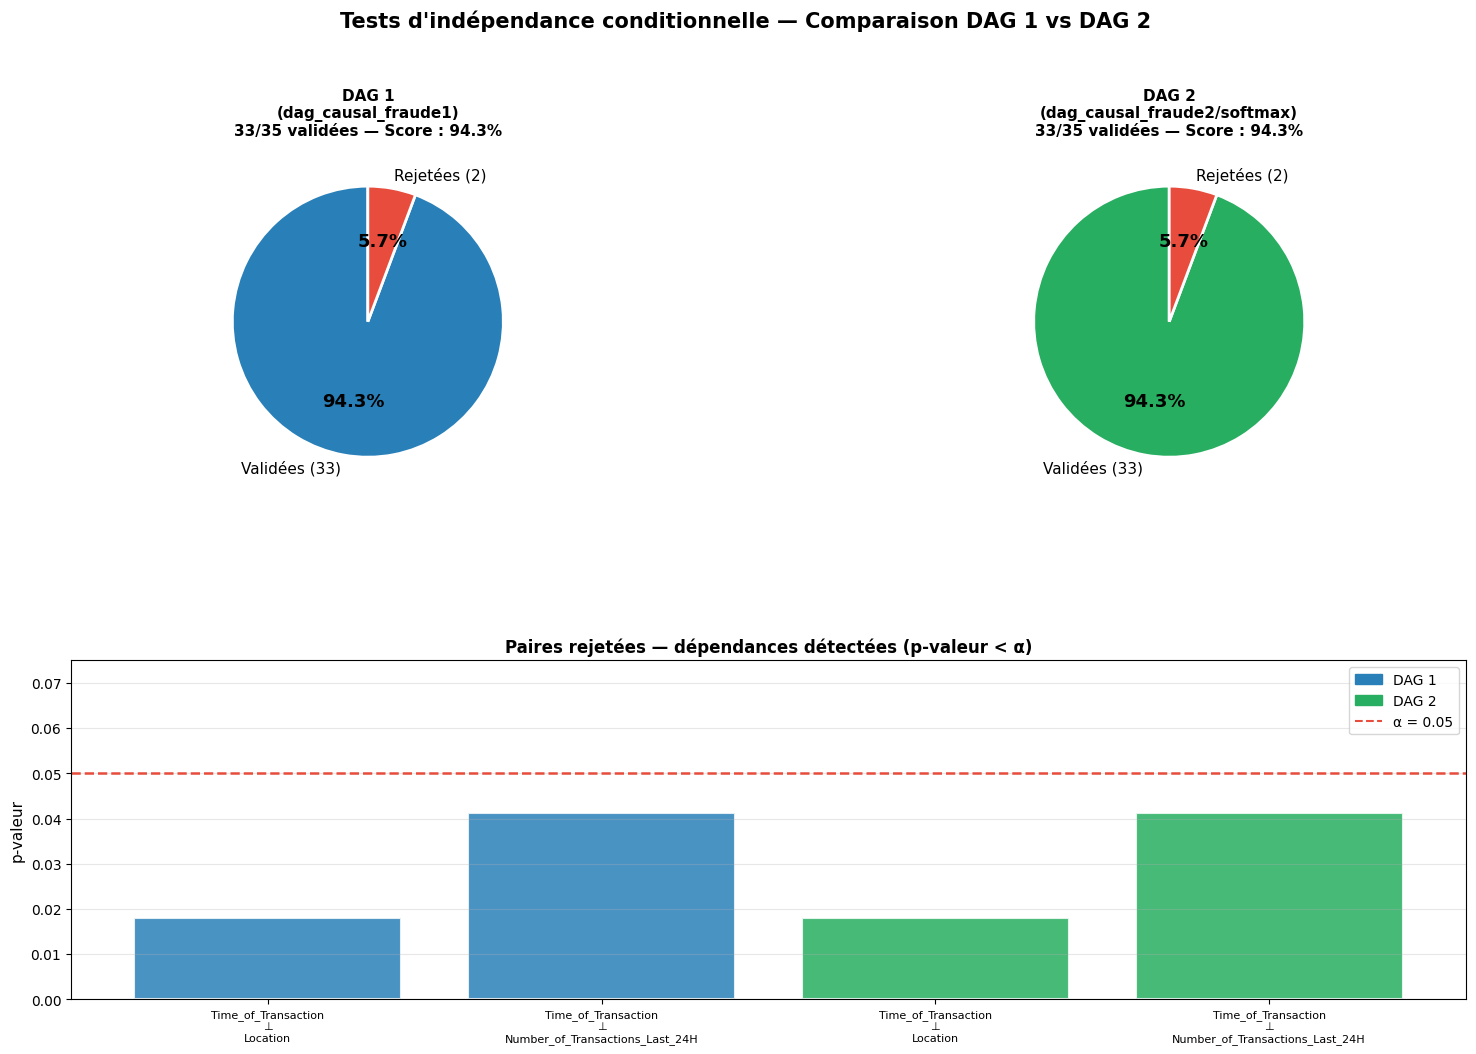


══════════════════════════════════════════════════════════════════════
  BILAN COMPARATIF
══════════════════════════════════════════════════════════════════════
  DAG                                      Paires  Validées    Score
  ──────────────────────────────────────────────────────────────────
  DAG 1 (dag_causal_fraude1)                   35        33    94.3%
  DAG 2 (dag_causal_fraude2 / softmax)         35        33    94.3%
══════════════════════════════════════════════════════════════════════

  Dépendances détectées — DAG 1 :
    ✗  Time_of_Transaction ⊥ Location | Z=[]
       p=0.0179  (Chi² mixte discrétisé | Z=[])
    ✗  Time_of_Transaction ⊥ Number_of_Transactions_Last_24H | Z=[]
       p=0.0412  (Corrélation partielle | Z=[])

  Dépendances détectées — DAG 2 :
    ✗  Time_of_Transaction ⊥ Location | Z=[]
       p=0.0179  (Chi² mixte discrétisé | Z=[])
    ✗  Time_of_Transaction ⊥ Number_of_Transactions_Last_24H | Z=[]
       p=0.0412  (Corrélation partielle | Z=[])

  

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# TESTS D'INDÉPENDANCE CONDITIONNELLE — DAG 1 vs DAG 2
# ═══════════════════════════════════════════════════════════════════════════════
import json
import itertools
import numpy as np
import pandas as pd
import networkx as nx
from scipy import stats
from scipy.stats import chi2_contingency
from numpy.linalg import lstsq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ───────────────────────────────────────────────────────────────────────────────
# 0. CHARGEMENT DES DAGs ET DU DATASET
# ───────────────────────────────────────────────────────────────────────────────
with open("dag_llm_basic.json", "r", encoding="utf-8") as f:
    dag1_data = json.load(f)

with open("dag_llm_softmax.json", "r", encoding="utf-8") as f:
    dag2_data = json.load(f)

# 'data' est déjà chargé dans la cellule 0 du notebook
COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]
df = data.drop(columns=COLONNES_EXCLUES, errors="ignore").copy()

COLS_CAT = df.select_dtypes(include=["object", "category"]).columns.tolist()
COLS_NUM = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
ALPHA    = 0.05
N_BINS   = 3

print(f"Dataset  : {df.shape[0]} lignes | {df.shape[1]} colonnes")
print(f"Catégor. : {COLS_CAT}")
print(f"Numér.   : {COLS_NUM}")


# ───────────────────────────────────────────────────────────────────────────────
# 1. CONSTRUCTION DES GRAPHES NETWORKX
# ───────────────────────────────────────────────────────────────────────────────
def dag_to_nx(dag_data: dict) -> nx.DiGraph:
    G = nx.DiGraph()
    G.add_nodes_from(dag_data["noeuds"])
    G.add_edges_from([(l["de"], l["vers"]) for l in dag_data["liens"]])
    return G

G1 = dag_to_nx(dag1_data)
G2 = dag_to_nx(dag2_data)

print(f"\nDAG 1 : {G1.number_of_nodes()} nœuds | {G1.number_of_edges()} liens")
print(f"DAG 2 : {G2.number_of_nodes()} nœuds | {G2.number_of_edges()} liens")


# ───────────────────────────────────────────────────────────────────────────────
# 2. D-SÉPARATION → ENSEMBLE SÉPARATEUR
# ───────────────────────────────────────────────────────────────────────────────
def get_separating_set(G: nx.DiGraph, X: str, Y: str) -> list:
    """
    Ensemble séparateur minimal pour (X, Y) :
    parents(X) ∪ parents(Y), sans X ni Y eux-mêmes.
    Couvre les configurations fork, chain et collider classiques.
    """
    sep = (set(G.predecessors(X)) | set(G.predecessors(Y))) - {X, Y}
    return list(sep)


# ───────────────────────────────────────────────────────────────────────────────
# 3. TESTS STATISTIQUES
# ───────────────────────────────────────────────────────────────────────────────
def discretiser(serie: pd.Series) -> pd.Series:
    """Discrétise une variable continue en N_BINS quantiles."""
    return pd.qcut(serie, q=N_BINS, labels=False, duplicates="drop")


def test_chi2(x: pd.Series, y: pd.Series) -> tuple:
    table = pd.crosstab(x, y)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, _, _ = chi2_contingency(table)
    return float(chi2), float(p)


def test_chi2_conditionnel(x: pd.Series, y: pd.Series, z: pd.Series) -> tuple:
    """
    Chi² conditionnel : stratification sur z (Cochran–Mantel–Haenszel simplifié).
    z est discrétisée si elle est numérique.
    """
    if z.name not in COLS_CAT:
        z = discretiser(z)

    chi2_total, ddl_total = 0.0, 0
    for strate in z.unique():
        mask = z == strate
        if mask.sum() < 5:
            continue
        tbl = pd.crosstab(x[mask], y[mask])
        if tbl.shape[0] < 2 or tbl.shape[1] < 2:
            continue
        c, _, d, _ = chi2_contingency(tbl)
        chi2_total += c
        ddl_total  += d

    if ddl_total == 0:
        return np.nan, np.nan
    p = float(1 - stats.chi2.cdf(chi2_total, df=ddl_total))
    return float(chi2_total), p


def test_partial_corr(x: pd.Series, y: pd.Series, z_df: pd.DataFrame) -> tuple:
    """
    Corrélation partielle X ⊥ Y | Z via résidus de régressions OLS.
    Si Z est vide → corrélation simple de Pearson.
    """
    local = pd.concat([x, y, z_df], axis=1).dropna()
    if len(local) < 10:
        return np.nan, np.nan

    x_col, y_col = x.name, y.name
    z_cols = z_df.columns.tolist()

    if not z_cols:
        r, p = stats.pearsonr(local[x_col], local[y_col])
        return float(r), float(p)

    Z      = np.column_stack([np.ones(len(local)), local[z_cols].values.astype(float)])
    res_x  = local[x_col].values - Z @ lstsq(Z, local[x_col].values, rcond=None)[0]
    res_y  = local[y_col].values - Z @ lstsq(Z, local[y_col].values, rcond=None)[0]
    r, p   = stats.pearsonr(res_x, res_y)
    return float(r), float(p)


def tester_independance(X: str, Y: str, Z: list, df: pd.DataFrame) -> dict:
    """
    Teste X ⊥ Y | Z et retourne stat, p-valeur, conclusion.
    Choisit automatiquement le test selon le type des variables.
    """
    idx   = df[X].dropna().index.intersection(df[Y].dropna().index)
    x_ser = df.loc[idx, X]
    y_ser = df.loc[idx, Y]
    z_df  = df.loc[idx, [c for c in Z if c in df.columns]]

    x_cat = X in COLS_CAT
    y_cat = Y in COLS_CAT

    # ── Cas 1 : deux catégorielles ──────────────────────────────────
    if x_cat and y_cat:
        if z_df.empty:
            stat, p = test_chi2(x_ser, y_ser)
            methode = "Chi² marginal"
        else:
            stat, p = test_chi2_conditionnel(x_ser, y_ser, z_df.iloc[:, 0])
            methode = f"Chi² conditionnel | Z={Z}"

    # ── Cas 2 : deux numériques ──────────────────────────────────────
    elif not x_cat and not y_cat:
        if z_df.empty:
            z_encoded = pd.DataFrame(index=idx)
        else:
            z_encoded = pd.get_dummies(z_df, drop_first=True).astype(float)
            if z_encoded.empty:
                z_encoded = pd.DataFrame(index=idx)
        stat, p = test_partial_corr(x_ser, y_ser, z_encoded)
        methode = f"Corrélation partielle | Z={Z}"

    # ── Cas 3 : mixte → discrétisation du numérique ─────────────────
    else:
        x_ser = discretiser(x_ser) if not x_cat else x_ser
        y_ser = discretiser(y_ser) if not y_cat else y_ser
        stat, p = test_chi2(x_ser, y_ser)
        methode = f"Chi² mixte discrétisé | Z={Z}"

    ok = bool(p > ALPHA) if (p is not None and not np.isnan(p)) else None
    return {
        "X"            : X,
        "Y"            : Y,
        "Z"            : Z,
        "methode"      : methode,
        "stat"         : round(stat, 4) if (stat is not None and not np.isnan(stat)) else None,
        "p_value"      : round(p,    4) if (p    is not None and not np.isnan(p))    else None,
        "independants" : ok,
        "conclusion"   : "✓ Indép. validée"    if ok is True  else
                         "✗ Dépendance détet."  if ok is False else
                         "? Indéfini"
    }


# ───────────────────────────────────────────────────────────────────────────────
# 4. PIPELINE PAR DAG
# ───────────────────────────────────────────────────────────────────────────────
def tester_dag(G: nx.DiGraph, df: pd.DataFrame, nom: str) -> pd.DataFrame:
    """
    Teste toutes les paires (X, Y) NON connectées dans G.
    """
    noeuds = list(G.nodes())
    paires = [
        (X, Y) for X, Y in itertools.combinations(noeuds, 2)
        if not G.has_edge(X, Y) and not G.has_edge(Y, X)
    ]

    print(f"\n{'═'*68}")
    print(f"  {nom}")
    print(f"  {G.number_of_nodes()} nœuds | {G.number_of_edges()} liens | {len(paires)} paires testées")
    print(f"{'═'*68}")

    resultats = []
    for X, Y in paires:
        Z   = get_separating_set(G, X, Y)
        res = tester_independance(X, Y, Z, df)
        resultats.append(res)
        icone = res["conclusion"].split()[0]
        z_aff = [z[:10] for z in Z] if Z else "∅"
        print(f"  {icone}  {X:<32} ⊥ {Y:<32} | Z={z_aff}   p={res['p_value']}")

    df_res   = pd.DataFrame(resultats)
    n_total  = len(df_res)
    n_valide = int(df_res["independants"].sum())
    taux     = n_valide / n_total * 100 if n_total else 0

    print(f"\n  → {n_valide}/{n_total} indépendances validées — Score cohérence : {taux:.1f}%")
    return df_res


# ───────────────────────────────────────────────────────────────────────────────
# 5. EXÉCUTION
# ───────────────────────────────────────────────────────────────────────────────
resultats_dag1 = tester_dag(G1, df, "DAG Basic (LLM sans softmax)")
resultats_dag2 = tester_dag(G2, df, "DAG Softmax (LLM + scoring softmax)")


# ───────────────────────────────────────────────────────────────────────────────
# 6. VISUALISATION
# ───────────────────────────────────────────────────────────────────────────────
def score_dag(df_res):
    n   = len(df_res)
    ok  = int(df_res["independants"].sum())
    return ok, n, ok / n * 100 if n else 0

v1, t1, s1 = score_dag(resultats_dag1)
v2, t2, s2 = score_dag(resultats_dag2)

rejets1 = resultats_dag1[resultats_dag1["independants"] == False].copy()
rejets2 = resultats_dag2[resultats_dag2["independants"] == False].copy()
rejets1["dag"] = "DAG 1"
rejets2["dag"] = "DAG 2"

fig = plt.figure(figsize=(18, 11), facecolor="white")
gs  = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.35)

# ── Camemberts ───────────────────────────────────────────────────────────────
for i, (nom, score, valide, total, color) in enumerate([
    ("DAG Basic\n(LLM sans softmax)",         s1, v1, t1, "#2980b9"),
    ("DAG Softmax\n(LLM + scoring softmax)", s2, v2, t2, "#27ae60"),
]):
    ax = fig.add_subplot(gs[0, i])
    valeurs  = [valide, total - valide]
    labels   = [f"Validées ({valide})", f"Rejetées ({total - valide})"]
    couleurs = [color, "#e74c3c"]
    wedges, texts, autotexts = ax.pie(
        valeurs, labels=labels, colors=couleurs,
        autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 11},
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    for at in autotexts:
        at.set_fontsize(13)
        at.set_fontweight("bold")
    ax.set_title(
        f"{nom}\n{valide}/{total} validées — Score : {score:.1f}%",
        fontsize=11, fontweight="bold", pad=12
    )

# ── Paires rejetées : p-valeurs ──────────────────────────────────────────────
ax_bot = fig.add_subplot(gs[1, :])
rejets_all = pd.concat([rejets1, rejets2], ignore_index=True)

if rejets_all.empty:
    ax_bot.text(
        0.5, 0.5,
        "Aucune dépendance détectée dans les deux DAGs.\n"
        "Le dataset est quasi-indépendant (corrélations ≈ 0, taux fraude uniforme ~5%).\n"
        "Les deux DAGs sont cohérents avec les données.",
        ha="center", va="center", fontsize=13, color="#555",
        transform=ax_bot.transAxes,
        bbox=dict(boxstyle="round,pad=0.8", facecolor="#f9f9f9", edgecolor="#ccc")
    )
    ax_bot.axis("off")
else:
    couleurs_dag = {"DAG 1": "#2980b9", "DAG 2": "#27ae60"}
    rejets_all["paire"] = rejets_all["X"] + "\n⊥\n" + rejets_all["Y"]
    x_pos = range(len(rejets_all))

    ax_bot.bar(
        x_pos,
        rejets_all["p_value"].fillna(0),
        color=[couleurs_dag[d] for d in rejets_all["dag"]],
        edgecolor="white", linewidth=1.5, alpha=0.85
    )
    ax_bot.axhline(ALPHA, color="#e74c3c", linestyle="--",
                   linewidth=1.8, label=f"Seuil α = {ALPHA}")
    ax_bot.set_xticks(list(x_pos))
    ax_bot.set_xticklabels(rejets_all["paire"], fontsize=8, ha="center")
    ax_bot.set_ylabel("p-valeur", fontsize=11)
    ax_bot.set_ylim(0, ALPHA * 1.5)
    ax_bot.set_title(
        "Paires rejetées — dépendances détectées (p-valeur < α)",
        fontsize=12, fontweight="bold"
    )
    ax_bot.legend(handles=[
        mpatches.Patch(color="#2980b9", label="DAG 1"),
        mpatches.Patch(color="#27ae60", label="DAG 2"),
        plt.Line2D([0], [0], color="#e74c3c", linestyle="--", label=f"α = {ALPHA}")
    ], fontsize=10)
    ax_bot.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Tests d'indépendance conditionnelle — Comparaison DAG 1 vs DAG 2",
    fontsize=15, fontweight="bold", y=1.01
)
plt.show()


# ───────────────────────────────────────────────────────────────────────────────
# 7. BILAN TEXTUEL
# ───────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*70)
print("  BILAN COMPARATIF")
print("═"*70)
print(f"  {'DAG':<40} {'Paires':>6} {'Validées':>9} {'Score':>8}")
print(f"  {'─'*66}")
print(f"  {'DAG Basic (LLM sans softmax)':<40} {t1:>6} {v1:>9} {s1:>7.1f}%")
print(f"  {'DAG Softmax (LLM + scoring softmax)':<40} {t2:>6} {v2:>9} {s2:>7.1f}%")
print("═"*70)

for nom, rejets in [("DAG 1", rejets1), ("DAG 2", rejets2)]:
    if not rejets.empty:
        print(f"\n  Dépendances détectées — {nom} :")
        for _, row in rejets.iterrows():
            print(f"    ✗  {row['X']} ⊥ {row['Y']} | Z={row['Z']}")
            print(f"       p={row['p_value']}  ({row['methode']})")
    else:
        print(f"\n  {nom} : aucune dépendance détectée ✓")

meilleur = "DAG 1" if s1 >= s2 else "DAG 2"
print(f"\n  Meilleur score    : {meilleur} ({max(s1, s2):.1f}%)")
print(f"  DAG le + contraint: {'DAG 2' if t2 > t1 else 'DAG 1'} ({max(t1,t2)} paires testées)")
print("\n  Note : scores similaires = dataset quasi-indépendant (corrélations ≈ 0).")
print("  La différence structurelle réelle est dans les paires rejetées, pas le score global.")